# ⭐⭐Tips CSV Data Analysis⭐⭐


##  ⭐Importing Libs and Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
df=pd.read_csv("tips.csv")

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 🔢 Step 1:  Five Number Summary

In [13]:
print('total bill summary:\n', df['total_bill'].describe())
print('tip summary:\n', df['tip'].describe()[['min', '25%', '50%', '75%', 'max' ]])

total bill summary:
 count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64
tip summary:
 min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64


## 📦 Step 2 : Boxplots for the Data

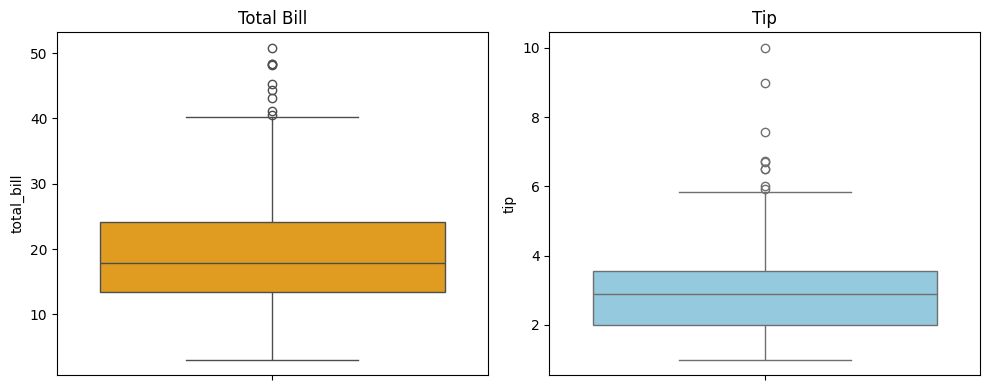

In [ ]:
# Boxplots for the Data
plt.figure(figsize=(10, 4))

# Boxplot for Total Bill and Tip
plt.subplot(1, 2, 1)
sns.boxplot(y=df['total_bill'], color='orange') ;plt.title('Total Bill')

# Boxplot for Tip
plt.subplot(1, 2, 2)
sns.boxplot(y=df['tip'], color='skyblue') ;plt.title('Tip')

# Plots 
plt.tight_layout() ; plt.show()


## 📓 Step 3 : IQR and Outlier Detection


IQR = Q3 -Q1 

min side outlier formula : Q1 -1.5 * IQR

max side outlier formula : Q3 -1.5 * IQR

In [22]:
# Quantiles
Q1b,Q3b=df['total_bill'].quantile([0.25,0.75])
Q1t,Q3t=df['tip'].quantile([0.25,0.75])

# Calculate IQR
IQR_bill,IQR_tip=Q3b-Q1b,Q3t-Q1t


# IQR method for Outlier Detection
out_bill=df[(df['total_bill'] < (Q1b-1.5*IQR_bill)) | (df['total_bill'] > (Q3b+1.5*IQR_bill))] # outliers
out_tip=df[(df['tip'] < (Q1t-1.5*IQR_tip)) | (df['tip'] > (Q3t+1.5*IQR_tip))]   # outliers

#Results
print(f"IQR(Total Bill) = {IQR_bill:.2f},Outliers: {len(out_bill)}") # length of outliers
print(f"IQR(Tip) = {IQR_tip:.2f},Outliers: {len(out_tip)}")  # length of outliers


IQR(Total Bill) = 10.78,Outliers: 9
IQR(Tip) = 1.56,Outliers: 9


## 📊 Step 4 : Histograms and Skewness

Right skewed graph has positive value

Left skewed graph has negative value

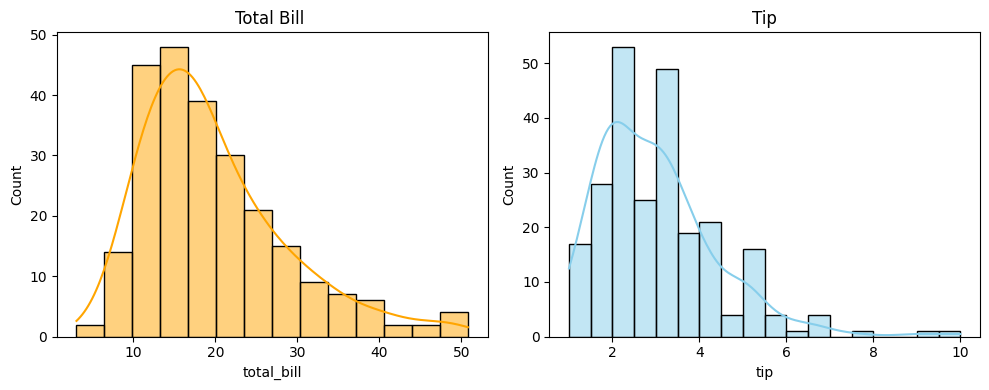

Skewness -> Total Bill : 1.13, Tip : 1.47


In [27]:
# Histograms and Skewness
plt.figure(figsize=(10,4)) 

# Plots
plt.subplot(1,2,1) ; sns.histplot(df['total_bill'], kde=True, color='orange') ; plt.title('Total Bill ')
plt.subplot(1,2,2) ; sns.histplot(df['tip'], kde=True, color='skyblue') ; plt.title('Tip')
plt.tight_layout() ; plt.show()

# Skewness
print(f'Skewness -> Total Bill : {df["total_bill"].skew():.2f}, Tip : {df["tip"].skew():.2f}')

## 📈 Step 5 : Cumulative Frequency Polygon

<function matplotlib.pyplot.show(close=None, block=None)>

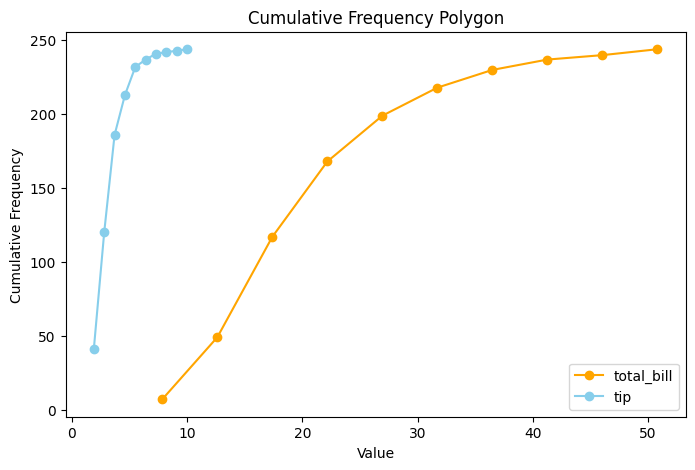

In [33]:
# Cumulative Frequency Polygon
plt.figure(figsize=(8,5))

# Plots
for col, color in zip(['total_bill','tip'], ['orange','skyblue']):
    count,bins=np.histogram(df[col], bins=10)
    plt.plot(bins[1:], np.cumsum(count) , marker='o', color=color, label=col)

# Labels
plt.title('Cumulative Frequency Polygon')
plt.xlabel('Value') ; plt.ylabel('Cumulative Frequency') ; plt.legend() ; plt.show